# Regression Example

This notebook provides two examples for performing basic regression on nonlinear data. The first example builds a traditional neural network and the second uses an affine observable PMM.

## Imports

In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import jax
import jax.numpy as np
import jax.random as jr
import parametricmatrixmodels as pmm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# enable x64 for JAX
jax.config.update("jax_enable_x64", True)

## Data Creation

(100, 1)
(100, 1)


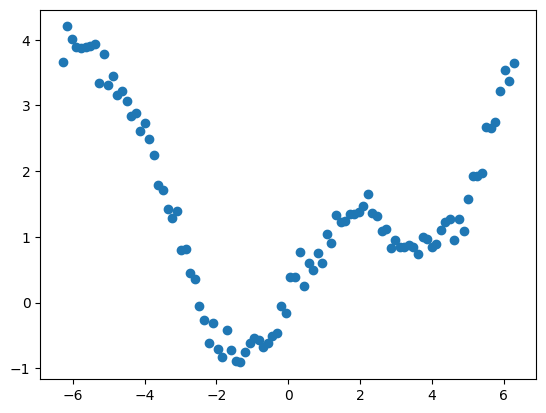

In [3]:
# random seed for reproducibility
SEED = 0
key = jr.key(SEED)

n_pnts = 100
X = np.linspace(-2 * np.pi, 2 * np.pi, n_pnts)
Y = np.sin(X) + 0.1 * X**2

# add noise
key, noise_key = jr.split(key)

Y = Y + 0.2 * jr.normal(noise_key, Y.shape)

# data must be in the shape [n_pnts, n_features] for the pmm library
X = X[:, None]
Y = Y[:, None]
print(X.shape)
print(Y.shape)

plt.plot(X, Y, 'o')

## Data Partitioning

In [4]:
# train on 70% of the data, validate on 15%, test on the rest
train_perc = 0.7
val_perc = 0.15

n_train = int(n_pnts * train_perc)
n_val = int(n_pnts * val_perc)
n_test = n_pnts - n_train - n_val

key, shuffle_key = jr.split(key)

# shuffle the data and then split
X_sh = jr.permutation(shuffle_key, X)
Y_sh = jr.permutation(shuffle_key, Y)

X_train = X_sh[:n_train]
Y_train = Y_sh[:n_train]
X_val = X_sh[n_train:n_train + n_val]
Y_val = Y_sh[n_train:n_train + n_val]
X_test = X_sh[n_train + n_val:]
Y_test = Y_sh[n_train + n_val:]

## Traditional Neural Network

### Data Preparation (Scaling)

Regression neural networks typically function best when the data are scaled to have unit variance and zero mean (`StandardScaler`)

In [5]:
xscaler = StandardScaler()
yscaler = StandardScaler()

X_train_sc = xscaler.fit_transform(X_train)
X_val_sc = xscaler.transform(X_val)
Y_train_sc = yscaler.fit_transform(Y_train)
Y_val_sc = yscaler.transform(Y_val)

# we need to convert the arrays back from numpy arrays to jax.numpy arrays, since sklearn uses pure numpy
X_train_sc = np.array(X_train_sc)
X_val_sc = np.array(X_val_sc)
Y_train_sc = np.array(Y_train_sc)
Y_val_sc = np.array(Y_val_sc)

### Model Creation

The model is built from an ordered sequence of `Module`s. For a traditional neural network, these are just `LinearNN` modules. Since we want linear sequential execution, we use a `SequentialModel`.

In [6]:
# two hidden layers with 64 neurons each and the ReLU activation function
# one output neuron
modules = [
        pmm.modules.LinearNN(
            out_features=64, bias=True, activation=pmm.modules.ReLU()
        ),
        pmm.modules.LinearNN(
            out_features=64, bias=True, activation=pmm.modules.ReLU()
        ),
        pmm.modules.LinearNN(out_features=1, bias=True),
    ]

model = pmm.SequentialModel(modules)

# print model summary before compilation
print(model)

SequentialModel(
  [
   LinearNN(
     []
   ),
   LinearNN(
     []
   ),
   LinearNN(
     []
   ),
  ]
)


We can see that the model summary is very sparse at the moment. This is because the model doesn't know what data to expect yet and doesn't have any initial values for trainable parameters.

### Model Compilation

It's more accurate to call this preparation or initialization, since all compilation happens JIT. This step doesn't _need_ to be done manually, as the model will automatically compile itself for the provided training data when the `Model.train` method is called.

Models are compiled by providing them with a random key or seed as well as the shape of the input data (excluding the batch dimension). This allows the model to prepare all its modules by, for instance, setting initial values for trainable parameters. Forward passes (inferences/predictions) cannot be done with Models (or Modules) until after compilation with the corresponding input shape.

In [7]:
key, compile_key = jr.split(key)

# the random key here can be replaced with an integer seed or None, in which case a random seed will be chosen
# the model only needs to know the input shape without the batch dimension
model.compile(key, X_train_sc.shape[1:])

# print the model summary after compilation
print(model)
print(f"Total trainable floats: {model.get_num_trainable_floats()}")

SequentialModel(
  [
   LinearNN(
     [
      Flatten,
      MatMul(trainable) (trainable floats: 64),
      Bias(real=True) (trainable floats: 64),
      ReLU,
     ]
   ),
   LinearNN(
     [
      Flatten,
      MatMul(trainable) (trainable floats: 4,096),
      Bias(real=True) (trainable floats: 64),
      ReLU,
     ]
   ),
   LinearNN(
     [
      Flatten,
      MatMul(trainable) (trainable floats: 64),
      Bias(real=True) (trainable floats: 1),
     ]
   ),
  ]
)
Total trainable floats: 4353


Now we see some actual details about the model. We can see it is built from 3 `LinearNN` Modules (which themselves are actually also Models) which use three to four submodules each: `Flatten`, a trainable `MatMul`, a trainable and real-valued `Bias`, and for the hidden layers `ReLU`. This represents the classic $f(Wx+b)$ neural network layer operation.

We can perform a forward pass (inference/prediction) with the randomly initialized model just to make sure everything is working:

In [8]:
model(np.array([[1.0]]))

Array([[-0.00960011]], dtype=float64)

### 64-bit versus 32-bit

By default, JAX disables 64-bit floating point support (double precision). This is re-enabled by calling `jax.config.update("jax_enable_x64", True)` after JAX is imported but _before_ it is initialized (usually before the first array operation). On certain hardware (like consumer GPUs) 64-bit operations can be nearly an order of magnitude slower than 32-bit. Additionally, there is little benefit to storing the trainable parameters of a model in 64-bit precision or for training models with 64-bit precision. It is for this reason that the PMM library defaults to (and will raise warnings otherwise) 32-bit models, 32-bit training, and 64-bit inference.

Here, we explicitly cast the model to 32-bit as well as the training/validation data.

In [9]:
model = model.astype(np.float32)

X_train_sc_32 = X_train_sc.astype(np.float32)
Y_train_sc_32 = Y_train_sc.astype(np.float32)
X_val_sc_32 = X_val_sc.astype(np.float32)
Y_val_sc_32 = Y_val_sc.astype(np.float32)

### Training

To train the model, we simply call the `model.train()` method and supply it with the training and validation data and optionally things like the loss function and options for the optimization process such as the learning rate, total number of epochs, batch size, etc.

In [10]:
key, batch_key = jr.split(key)

model.train(
    X_train_sc_32,
    Y=Y_train_sc_32,
    X_val=X_val_sc_32,
    Y_val=Y_val_sc_32,
    lr=1e-2,
    epochs=250,
    batch_size=5,
    batch_rng=batch_key,
    verbose=True)


Total epochs: 250
(best epoch: 245)
(best validation loss: 2.1437E-02)


139/250 | 6.6578e-02/5.1926e-02 [####################] (0s)
140/250 | 5.4720e-02/5.1926e-02 [####################] (0s)
141/250 | 6.1397e-02/5.1926e-02 [####################] (0s)
142/250 | 4.6176e-02/4.6176e-02 [####################] (0s)
143/250 | 5.6338e-02/4.6176e-02 [####################] (0s)
144/250 | 5.9826e-02/4.6176e-02 [####################] (0s)
145/250 | 5.2593e-02/4.6176e-02 [####################] (0s)
146/250 | 4.7631e-02/4.6176e-02 [####################] (0s)
147/250 | 6.0039e-02/4.6176e-02 [####################] (0s)
148/250 | 5.1952e-02/4.6176e-02 [####################] (0s)
149/250 | 6.4384e-02/4.6176e-02 [####################] (0s)
150/250 | 4.7902e-02/4.6176e-02 [####################] (0s)
151/250 | 5.4240e-02/4.6176e-02 [####################] (0s)
152/250 | 8.7593e-02/4.6176e-02 [####################] (0s)
153/250 | 5.5680e-02/4.6176e-02 [####################] (0s)
154/250 | 5.9909e-02/4.6176e-02 [####################] (0s)
155/250 | 4.5948e-02/4.5948e-02 [#######

### Inference

Now we're ready to make new predictions with the model. All Models and Modules are directly callable once compiled, so we need only to pass in the (scaled) inputs like `model(X)` and unscale the predictions.

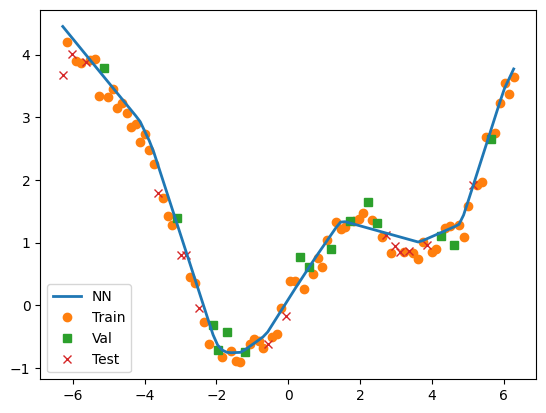

In [11]:
# pass in the scaled inputs (converted to JAX arrays again)
X_sc = xscaler.transform(X)
X_sc = np.array(X_sc)

# get scaled predictions
Y_pred_sc = model(X_sc)

# unscale predictions
Y_pred = yscaler.inverse_transform(Y_pred_sc)

# plot results
plt.plot(X, Y_pred, label="NN", lw=2, zorder=10)
plt.plot(X_train, Y_train, 'o', label="Train")
plt.plot(X_val, Y_val, 's', label="Val")
plt.plot(X_test, Y_test, 'x', label="Test")
plt.legend()

## Parametric Matrix Model (`AffineObservablePMM`)

Here we repeat the above process for the `AffineObservablePMM`, which is both a Module and a Model. For consistency, we wrap it with a `SequentialModel`, though this isn't necessary as it is itself a subclass of `SequentialModel`. The only other difference in usage here is that this kind of PMM performs best when the data are scaled uniformly, using `MinMaxScaler`.

### Data Preparation (Scaling)

This kind of PMM typically functions best when the data are scaled uniformly (`MinMaxScaler`)

In [12]:
xscaler = MinMaxScaler()
yscaler = MinMaxScaler()

X_train_sc = xscaler.fit_transform(X_train)
X_val_sc = xscaler.transform(X_val)
Y_train_sc = yscaler.fit_transform(Y_train)
Y_val_sc = yscaler.transform(Y_val)

# we need to convert the arrays back from numpy arrays to jax.numpy arrays, since sklearn uses pure numpy
X_train_sc = np.array(X_train_sc)
X_val_sc = np.array(X_val_sc)
Y_train_sc = np.array(Y_train_sc)
Y_val_sc = np.array(Y_val_sc)

### Model Creation

This model is a single `AffineObservablePMM` module with a Hermitian matrices size of `5`, two eigenvectors, one secondary matrix, and using expectation values instead of transition amplitudes. Internally, this Module is just a `SequentialModel` of Modules that first form the primary matrix $H(c) = H_0 + \sum_i c_i H_i$, then take the eigendecomposition, then compute the sum of transition amplitudes or expectation values with trainable secondary matrices, then finally add a trainable bias.

In [13]:
# just a single PMM module, which contains all the submodules
modules = [
        pmm.modules.AffineObservablePMM(
            matrix_size=5,
            num_eig=2,
            num_secondaries=1,
            output_size=1,
            use_expectation_values=True
        )
    ]

model = pmm.SequentialModel(modules)

# print model summary before compilation
print(model)
print(f"Total trainable floats: {model.get_num_trainable_floats()}")

SequentialModel(
  [
   AffineObservablePMM(
     []
   ),
  ]
)
Total trainable floats: 0


We can see that the model summary is very sparse at the moment. This is because the model doesn't know what data to expect yet and doesn't have any initial values for trainable parameters.

### Model Compilation

It's more accurate to call this preparation or initialization, since all compilation happens JIT. This step doesn't _need_ to be done manually, as the model will automatically compile itself for the provided training data when the `Model.train` method is called.

Models are compiled by providing them with a random key or seed as well as the shape of the input data (excluding the batch dimension). This allows the model to prepare all its modules by, for instance, setting initial values for trainable parameters. Forward passes (inferences/predictions) cannot be done with Models (or Modules) until after compilation with the corresponding input shape.

In [14]:
key, compile_key = jr.split(key)

# the random key here can be replaced with an integer seed or None, in which case a random seed will be chosen
# the model only needs to know the input shape without the batch dimension
model.compile(key, X_train_sc.shape[1:])

# print the model summary after compilation
print(model)

SequentialModel(
  [
   AffineObservablePMM(
     (
      AffineHermitianMatrix(5x5) (trainable floats: 50),
      Eigenvectors(num_eig=2, which=LM),
      ExpectationValueSum(output_size=1, num_observables=1, centered=True) (trainable floats: 25),
      Bias(real=True) (trainable floats: 1),
     )
   ),
  ]
)


Now we see some actual details about the model. We can see it is built from 1 `AffineObservablePMM` Module (which itself is a Model) which uses four submodules: `AffineHermitianMatrix`, `Eigenvectors`, `ExpectationValueSum`, and `Bias`.

We can perform a forward pass (inference/prediction) with the randomly initialized model just to make sure everything is working:

In [15]:
model(np.array([[1.0]]))

Array([[0.01202144]], dtype=float64)

### 64-bit versus 32-bit

By default, JAX disables 64-bit floating point support (double precision). This is re-enabled by calling `jax.config.update("jax_enable_x64", True)` after JAX is imported but _before_ it is initialized (usually before the first array operation). On certain hardware (like consumer GPUs) 64-bit operations can be nearly an order of magnitude slower than 32-bit. Additionally, there is little benefit to storing the trainable parameters of a model in 64-bit precision or for training models with 64-bit precision. It is for this reason that the PMM library defaults to (and will raise warnings otherwise) 32-bit models, 32-bit training, and 64-bit inference.

Here, we explicitly cast the model to 32-bit as well as the training/validation data.

In [16]:
model = model.astype(np.float32)

X_train_sc_32 = X_train_sc.astype(np.float32)
Y_train_sc_32 = Y_train_sc.astype(np.float32)
X_val_sc_32 = X_val_sc.astype(np.float32)
Y_val_sc_32 = Y_val_sc.astype(np.float32)

### Training

To train the model, we simply call the `model.train()` method and supply it with the training and validation data and optionally things like the loss function and options for the optimization process such as the learning rate, total number of epochs, batch size, etc.

In [17]:
# using the same batch key as with the neural network
model.train(
    X_train_sc_32,
    Y=Y_train_sc_32,
    X_val=X_val_sc_32,
    Y_val=Y_val_sc_32,
    lr=1e-2,
    epochs=250,
    batch_size=5,
    batch_rng=batch_key,
    verbose=True)


Total epochs: 250
(best epoch: 188)
(best validation loss: 1.8272E-03)


139/250 | 1.9903e-03/1.9056e-03 [####################] (0s)
140/250 | 1.9782e-03/1.9056e-03 [####################] (0s)
141/250 | 1.9603e-03/1.9056e-03 [####################] (0s)
142/250 | 2.7303e-03/1.9056e-03 [####################] (0s)
143/250 | 5.9771e-03/1.9056e-03 [####################] (0s)
144/250 | 4.0507e-03/1.9056e-03 [####################] (0s)
145/250 | 2.1805e-03/1.9056e-03 [####################] (0s)
146/250 | 1.7523e-03/1.7523e-03 [####################] (0s)
147/250 | 2.2935e-03/1.7523e-03 [####################] (0s)
148/250 | 3.1664e-03/1.7523e-03 [####################] (0s)
149/250 | 3.0230e-03/1.7523e-03 [####################] (0s)
150/250 | 2.4747e-03/1.7523e-03 [####################] (0s)
151/250 | 3.7523e-03/1.7523e-03 [####################] (0s)
152/250 | 5.4125e-03/1.7523e-03 [####################] (0s)
153/250 | 2.5811e-03/1.7523e-03 [####################] (0s)
154/250 | 4.2159e-03/1.7523e-03 [####################] (0s)
155/250 | 3.1262e-03/1.7523e-03 [#######

### Inference

Now we're ready to make new predictions with the model. All Models and Modules are directly callable once compiled, so we need only to pass in the (scaled) inputs like `model(X)` and unscale the predictions.

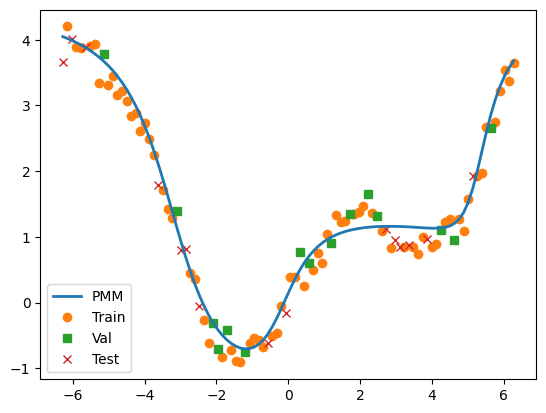

In [18]:
# pass in the scaled inputs (converted to JAX arrays again)
X_sc = xscaler.transform(X)
X_sc = np.array(X_sc)

# get scaled predictions
Y_pred_sc = model(X_sc)

# unscale predictions
Y_pred = yscaler.inverse_transform(Y_pred_sc)

# plot results
plt.plot(X, Y_pred, label="PMM", lw=2, zorder=10)
plt.plot(X_train, Y_train, 'o', label="Train")
plt.plot(X_val, Y_val, 's', label="Val")
plt.plot(X_test, Y_test, 'x', label="Test")
plt.legend()